In [1]:
# import packages
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm
from torchinfo import summary
import os
import matplotlib.pyplot as plt


import math
from pathlib import Path

# .py scripts imports
import sys
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))
from utils.data_load import DataModule # used to load dataset and create dataloaders
from utils.checkpoint import ModelCheckpoint
from utils.logging import save_history
from utils.losses import (masked_l1_loss, # for 0.5 and 2.0 second 
                          masked_l1_grad_loss,
                          masked_huber_loss,
                          masked_multires_l1_loss, # for 3.0 and 5.0 second gaps

                          # evaluation metrics
                          masked_mae,
                          masked_rmse,
                          full_mae,
                          full_rmse,
                          psnr
                        )

/Users/ngjunhan/opt/anaconda3/envs/dl_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
# define checkpoints and history 
root_dir = Path("training_logs/cnn_ae_")
# root_dir.mkdir(parents=True, exist_ok=True)

checkpoint_dir = root_dir / "checkpoints"
history_dir = root_dir / "history" 

checkpoint_dir.mkdir(parents=True, exist_ok=True)
history_dir.mkdir(parents=True, exist_ok=True)

### **Load Data**

In [ ]:
# load in dataset and create dataloaders using data_load.datamodule class
# using datamodule class to load data
dm = DataModule(
    repo_id="han2o/grant-ortsaem-processedV3", # hugging face repo id for dataset
    variant="short_gaps",                      # short_gap (0.5 to 2.0) or long_gap(0.5 to 5.0)
    input_key="masked_spectrogram",
    target_key="spectrogram",
    mask_key="mask",
    batch_size=8,                             # batch size for dataloaders
    num_workers=0,
    streaming=True,
    # maximum number of training/ validation/ test samples. Set to None to use the entire dataset.
    max_train_samples=10000, 
    max_val_samples=100,
    max_test_samples=100, 
)

train_loader, val_loader, test_loader = dm.setup()

In [5]:
# inspect one batch of data
batch = next(iter(train_loader))

print("keys:", batch.keys())
print("x shape:", batch["x"].shape)
print("y shape:", batch["y"].shape)
print("mask shape:", batch["mask"].shape)

if "gap_seconds" in batch:
    print("example gap:", batch["gap_seconds"][0])

keys: dict_keys(['x', 'y', 'mask', 'example_id', 'split', 'recording_idx', 'clip_idx', 'audio_filename', 'sample_rate', 'clip_duration_seconds', 'n_mels', 'time_frames', 'hop_length', 'gap_seconds', 'gap_frames', 'mask_start_frame', 'mask_end_frame'])
x shape: torch.Size([16, 1, 128, 1876])
y shape: torch.Size([16, 1, 128, 1876])
mask shape: torch.Size([16, 1, 128, 1876])
example gap: tensor(1.4394, dtype=torch.float64)


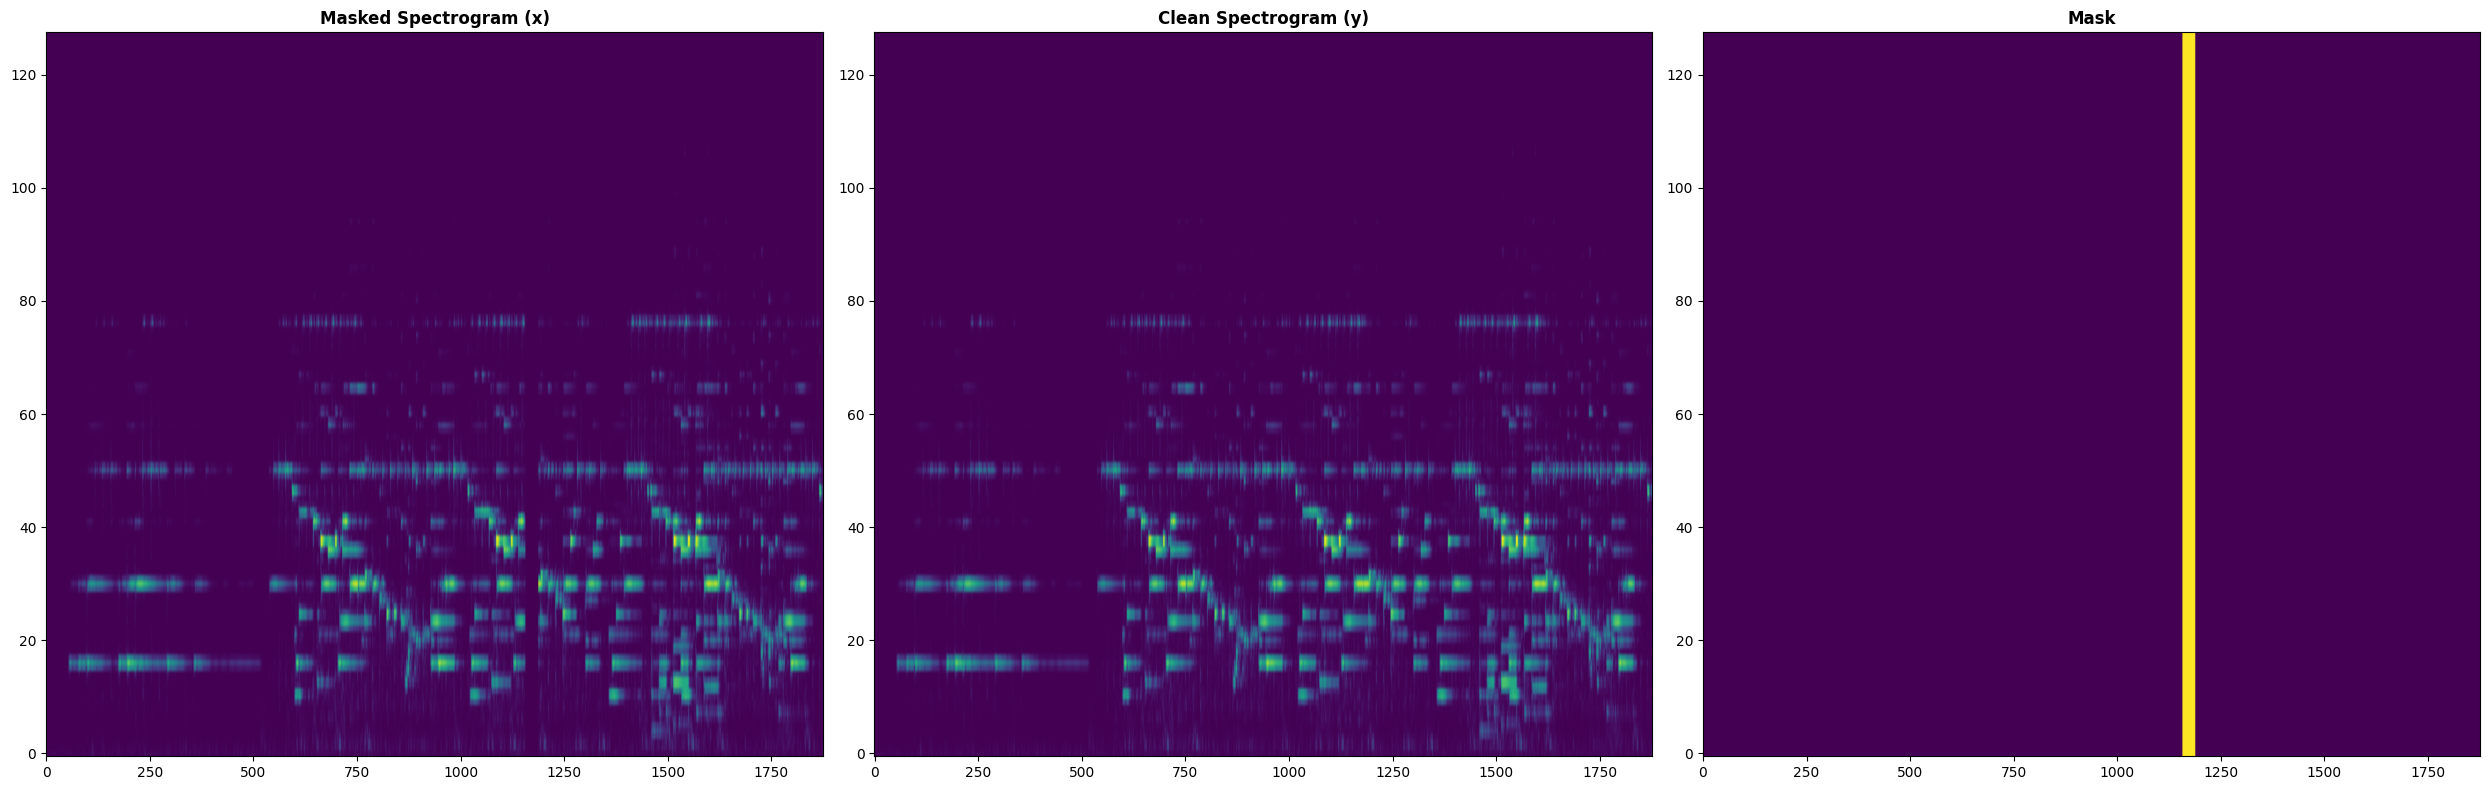

In [19]:
# visualise a sample spectrogram, mask, and target
x = batch["x"][0, 0].cpu().numpy()
y = batch["y"][0, 0].cpu().numpy()
m = batch["mask"][0, 0].cpu().numpy()

plt.figure(figsize=(25, 8))

plt.subplot(1, 3, 1)
plt.imshow(x, aspect="auto", origin="lower")
plt.title("Masked Spectrogram (x)", weight="bold")

plt.subplot(1, 3, 2)
plt.imshow(y, aspect="auto", origin="lower")
plt.title("Clean Spectrogram (y)", weight="bold")

plt.subplot(1, 3, 3)
plt.imshow(m, aspect="auto", origin="lower")
plt.title("Mask", weight="bold")

plt.tight_layout()
plt.show()

### **CNN AutoEncoder**


#### **Helper Class Blocks**

In [ ]:
# squeeze and excitation block to learn channel-wise importance weights
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        # reduce channel dimension in the small gating network
        hidden = max(channels // reduction, 8)

        # global average pooling: converts each channel from (H, W) into a single summary value
        self.pool = nn.AdaptiveAvgPool2d(1) # (B, C, 1, 1)

        # first 1x1 convolution: reduces the number of channels to a smaller hidden size
        self.fc1 = nn.Conv2d(channels, hidden, kernel_size=1)

        # second 1x1 convolution: maps the hidden representation back to the original number of channels
        self.fc2 = nn.Conv2d(hidden, channels, kernel_size=1)

    # forward pass
    def forward(self, x):
        #squeeze spatial information into one value per channel
        scale = self.pool(x)

        # small nonlinear transformation
        scale = F.silu(self.fc1(scale))

        # produce channel weights between 0 and 1
        scale = torch.sigmoid(self.fc2(scale))

        # reweight original feature map channel-wise
        return x * scale

# efficientnet MBConvBlock, expands channels with 1 by 1 convolution and apply depthwise convolution then apply SE attention
# and projects back to desired output channels, later on it adds aresidual connection
class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expansion=4, kernel_size=3, se_reduction=8):
        super().__init__()

        # use residual only when input and output channle match
        self.use_residual = (in_channels == out_channels)

        # expanded channel dimension inside the block
        self.use_expand = expansion > 1 
        hidden_dim = in_channels * expansion if self.use_expand else in_channels

        if self.use_expand:
            # 1x1 expansion convolution: increases channel capacity 
            self.expand = nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False)
            self.bn1 = nn.BatchNorm2d(hidden_dim)

        # depthwise convolution: applies one spatial filter per channel separately
        # groups = hidden_dim means each channel is convolved independently
        self.depthwise = nn.Conv2d(
            hidden_dim,
            hidden_dim,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            groups=hidden_dim,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(hidden_dim)

        # SE attention block
        self.se = SEBlock(hidden_dim, reduction=se_reduction)

        # 1x1 projection convolution: compresses channels back down to out_channels.
        self.project = nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        oput = x

        if self.use_expand:
            # expand channels
            out = self.expand(x)
            out = F.silu(self.bn1(out))

        # learn spatial patterns channel-by-channel
        out = self.depthwise(out)
        out = F.silu(self.bn2(out))

        # channel attention
        out = self.se(out)

        # project back to output channel size
        out = self.project(out)
        out = self.bn3(out)

        # add skip connection
        if self.use_residual:
            out = out + x

        # final nonlinearity
        return F.silu(out)

# cheap residual conv block for high-resolution stages
class LightConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # only use identity residual if channel dims match, otherwise project with 1x1 conv
        self.use_residual = (in_channels == out_channels)

        # two 3x3 conv layers with batch norm
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # 1x1 projection for skip connection when channel dims differ
        if not self.use_residual:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        else:
            self.skip = None

    def forward(self, x):
        identity = x

        # main path, conv -> norm -> activation -> conv -> norm
        out = self.conv1(x)
        out = F.silu(self.bn1(out))
        out = self.conv2(out)
        out = self.bn2(out)

        # residual addition, identity if dims match, projected skip otherwise
        if self.use_residual:
            out = out + identity
        else:
            out = out + self.skip(identity)

        # final activation after residual addition
        return F.silu(out)

### **Build CNN AutoEncoder**

In [ ]:
# CNN autoencoder
class CNNAutoencoder(nn.Module):
    def __init__(self, base_channels=24):
        super().__init__()

        c1 = base_channels 
        c2 = base_channels * 2  # 24
        c3 = base_channels * 4  # 48
        c4 = base_channels * 8  # 192

        # stem layer that combines the 2-channel input into an initial feature representation
        self.stem = nn.Sequential(
            nn.Conv2d(2, c1, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.SiLU()
        )

        # encoder layer

        # 1st encoder stage
        self.enc1 = LightConvBlock(c1, c1) # in higher resolution we use a cheaper conv block

        # downsampel 1, halves time and frequency resolution, increases channels
        self.down1 = nn.Conv2d(c1, c2, kernel_size=3, stride=2, padding=1, bias=False)

        # 2nd encoder stage
        self.enc2 = MBConvBlock(c2, c2, expansion=2, kernel_size=3, se_reduction=8)

        # dwonsample 2
        self.down2 = nn.Conv2d(c2, c3, kernel_size=3, stride=2, padding=1, bias=False)

        # 3rd encoder stage
        self.enc3 = MBConvBlock(c3, c3, expansion=3, kernel_size=5, se_reduction=8)

        # downsample 3
        self.down3 = nn.Conv2d(c3, c4, kernel_size=3, stride=2, padding=1, bias=False)


        # bottleneck layer, stores compressed representation of spectrogram
        self.bottleneck = nn.Sequential(
            MBConvBlock(c4, c4, expansion=3, kernel_size=5, se_reduction=8),
            MBConvBlock(c4, c4, expansion=3, kernel_size=3, se_reduction=8)
        )

        # decoder

        # upsample 1, doubling the spatial size
        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        # 1st decoder stage, refines features after upsampling and reduces channel count
        self.dec1 = MBConvBlock(c4, c3, expansion=2, kernel_size=5, se_reduction=8)

        # upsample 2
        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        # 2nd decoder stage 
        self.dec2 = MBConvBlock(c3, c2, expansion=2, kernel_size=3, se_reduction=8)

        # upsample 3
        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        # 3rd decoder stage
        self.dec3 = LightConvBlock(c2, c1)

        # final output layer
        self.final_conv = nn.Conv2d(c1, 1, kernel_size=1)

    # forward pass
    def forward(self, x, mask, return_intermediates=False):
        # concatenate masked spectrogram and mask along channel dimension
        inp = torch.cat([x, mask], dim=1)

        # initial feature extraction
        h0 = self.stem(inp)

        # encoder
        h1 = self.enc1(h0)
        h1d = F.silu(self.down1(h1))

        h2 = self.enc2(h1d)
        h2d = F.silu(self.down2(h2))

        h3 = self.enc3(h2d)
        h3d = F.silu(self.down3(h3))

        # bottleneck
        hb = self.bottleneck(h3d)

        # decoder
        u1 = self.up1(hb)
        d1 = self.dec1(u1)

        u2 = self.up2(d1)
        d2 = self.dec2(u2)

        u3 = self.up3(d2)
        d3 = self.dec3(u3)

        # map features back to a single reconstructed spectrogram channel
        out = self.final_conv(d3)

        # safety step:
        # resize back if the output spatial size differs from the input
        if out.shape[-2:] != x.shape[-2:]:
            out = F.interpolate(out, size=x.shape[-2:], mode="bilinear", align_corners=False)

        if return_intermediates:
            return {
                "stem": h0,
                "enc1": h1,
                "enc2": h2,
                "enc3": h3,
                "bottleneck": hb,
                "dec1": d1,
                "dec2": d2,
                "dec3": d3,
                "out": out,
            }

        return out


In [ ]:
model = CNNAutoencoder(base_channels=16).cpu()
x = torch.randn(1, 1, 128, 256)
mask = torch.randn(1, 1, 128, 256)
summary(model, input_data=(x, mask))

Layer (type:depth-idx)                        Output Shape              Param #
CNNAutoencoder                                [4, 1, 128, 256]          --
├─Sequential: 1-1                             [4, 32, 128, 256]         --
│    └─Conv2d: 2-1                            [4, 32, 128, 256]         576
│    └─BatchNorm2d: 2-2                       [4, 32, 128, 256]         64
│    └─SiLU: 2-3                              [4, 32, 128, 256]         --
├─MBConvBlock: 1-2                            [4, 32, 128, 256]         --
│    └─Conv2d: 2-4                            [4, 64, 128, 256]         2,048
│    └─BatchNorm2d: 2-5                       [4, 64, 128, 256]         128
│    └─Conv2d: 2-6                            [4, 64, 128, 256]         576
│    └─BatchNorm2d: 2-7                       [4, 64, 128, 256]         128
│    └─SEBlock: 2-8                           [4, 64, 128, 256]         --
│    │    └─AdaptiveAvgPool2d: 3-1            [4, 64, 1, 1]             --
│    │    └─C

In [ ]:
# selectiing loss functions
def get_loss(variant="short_gap", shortgap_loss="masked_l1_grad", longgap_loss="masked_multires_l1_grad"
             ):
    if variant == "short_gap":
        loss = shortgap_loss
    elif variant == "long_gap":
        loss = longgap_loss
    else:
        raise ValueError(
            f"Invalid gap variant {variant}."
        )

    return loss

# compute loss 
def compute_loss(pred, target, mask, loss="masked_l1_grad"):
    # masked l1
    if loss == "masked_l1":
        total_loss, gap_loss, context_loss = masked_l1_loss(pred, target, mask)
        loss_dict = {
            "loss": total_loss.item(),
            "gap_loss": gap_loss.item(),
            "context_loss": context_loss.item(),
        }
    # masked l1 gradient
    elif loss == "masked_l1_grad":
        total_loss, gap_loss, context_loss, grad_loss = masked_l1_grad_loss(pred, target, mask)
        loss_dict = {
            "loss": total_loss.item(),
            "gap_loss": gap_loss.item(),
            "context_loss": context_loss.item(),
            "grad_loss": grad_loss.item(),
        }

    # masked huber
    elif loss == "masked_huber":
        total_loss, gap_loss, context_loss = masked_huber_loss(pred, target, mask)
        loss_dict = {
            "loss": total_loss.item(),
            "gap_loss": gap_loss.item(),
            "context_loss": context_loss.item(),
        }

    # maskd multiresolution l1
    elif loss == "masked_multires_l1":
        total_loss, gap_loss, context_loss = masked_multires_l1_loss(pred, target, mask)
        loss_dict = {
            "loss": total_loss.item(),
            "gap_loss": gap_loss.item(),
            "context_loss": context_loss.item(),
        }

    else:
        raise ValueError(f"Unknown loss_name: {loss}")

    return total_loss, loss_dict


In [ ]:
# compute evaluation metrics
def compute_metrics(pred, target, mask):
    metrics = {"gap_mae": masked_mae(pred, target, mask).item(),
               "gap_rmse": masked_rmse(pred, target, mask).item(),
               "full_mae": full_mae(pred, target).item(),
               "full_rmse": full_rmse(pred, target).item(),
               "psnr": psnr(pred, target).item(),
            }
    return metrics

In [ ]:
# train model for one full epoch
def train_epoch(model, dataloader, optimiser, device, loss, grad_clip=1.0, use_amp=True):
    # set model to training mode
    model.train()

    # running sums for all metrics to average over the epoch
    running = {
        "loss": 0.0,
        "gap_loss": 0.0,
        "context_loss": 0.0,
        "grad_loss": 0.0,
        "gap_mae": 0.0,
        "gap_rmse": 0.0,
        "full_mae": 0.0,
        "full_rmse": 0.0,
        "psnr": 0.0,
    }

    num_batches = 0

    # only enable AMP scaler when running on CUDA
    use_amp = use_amp and ("cuda" in str(device))
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    # loop through all batches in the training set
    for batch in tqdm(dataloader):
        # move input tensors to device
        x = batch["x"].to(device, non_blocking=True)       # masked spectrogram
        y = batch["y"].to(device, non_blocking=True)       # clean target spectrogram
        mask = batch["mask"].to(device, non_blocking=True) # binary gap mask

        # reset old gradients before computing new ones
        optimiser.zero_grad(set_to_none=True)

        # mixed precision forward pass
        with torch.amp.autocast("cuda", enabled=use_amp):
            # forward pass: predict reconstructed spectrogram
            pred = model(x, mask)

            # compute chosen training loss
            total_loss, loss_dict = compute_loss(pred, y, mask, loss=loss)

        # backward pass with gradient scaling
        scaler.scale(total_loss).backward()

        # unscale gradients before clipping
        if grad_clip is not None:
            scaler.unscale_(optimiser)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        # update model parameters
        scaler.step(optimiser)
        scaler.update()

        # compute evaluation metrics outside autocast for stable logging
        with torch.no_grad():
            eval_dict = compute_metrics(pred.float(), y.float(), mask.float())

        # accumulate loss metrics
        for key in loss_dict:
            if key in running:
                running[key] += loss_dict[key].item() if torch.is_tensor(loss_dict[key]) else float(loss_dict[key])

        # accumulate eval metrics
        for key in eval_dict:
            if key in running:
                running[key] += eval_dict[key].item() if torch.is_tensor(eval_dict[key]) else float(eval_dict[key])

        num_batches += 1

    # average all metrics across batches
    epoch_metrics = {k: v / max(num_batches, 1) for k, v in running.items()}
    return epoch_metrics


# evaluate model for one full epoch
@torch.no_grad()
def eval_epoch(model, dataloader, device, loss, use_amp=True):
    # set model to evaluation mode
    model.eval()

    running = {
        "loss": 0.0,
        "gap_loss": 0.0,
        "context_loss": 0.0,
        "grad_loss": 0.0,
        "gap_mae": 0.0,
        "gap_rmse": 0.0,
        "full_mae": 0.0,
        "full_rmse": 0.0,
        "psnr": 0.0,
    }

    num_batches = 0

    # only enable AMP when running on CUDA
    use_amp = use_amp and ("cuda" in str(device))

    # loop over validation data
    for batch in dataloader:
        # move tensors to device
        x = batch["x"].to(device, non_blocking=True)
        y = batch["y"].to(device, non_blocking=True)
        mask = batch["mask"].to(device, non_blocking=True)

        # forward pass only with mixed precision
        with torch.amp.autocast("cuda", enabled=use_amp):
            pred = model(x, mask)

            # compute loss values for logging
            total_loss, loss_dict = compute_loss(pred, y, mask, loss=loss)

        # compute evaluation metrics in full precision for stable logging
        eval_dict = compute_metrics(pred.float(), y.float(), mask.float())

        # accumulate metrics
        for key in loss_dict:
            if key in running:
                running[key] += loss_dict[key].item() if torch.is_tensor(loss_dict[key]) else float(loss_dict[key])

        for key in eval_dict:
            if key in running:
                running[key] += eval_dict[key].item() if torch.is_tensor(eval_dict[key]) else float(eval_dict[key])

        num_batches += 1

    # average all metrics across batches
    epoch_metrics = {k: v / max(num_batches, 1) for k, v in running.items()}
    return epoch_metrics

In [ ]:
# full training loop
def fit_CNNAE(model, train_loader, val_loader, optimiser, device, n_epochs,
             checkpoint_dir, history_csv_path, loss=loss, monitor="val_gap_rmse",
             mode="min", patience=5, min_delta=1e-4, save_best_after_epoch=5,
             grad_clip=1.0):
    
    # history dictionary storing one list per metric
    history = {
        "epoch": [],
        "train_loss": [],
        "train_gap_loss": [],
        "train_context_loss": [],
        "train_grad_loss": [],
        "train_gap_mae": [],
        "train_gap_rmse": [],
        "train_full_mae": [],
        "train_full_rmse": [],
        "train_psnr": [],
        "val_loss": [],
        "val_gap_loss": [],
        "val_context_loss": [],
        "val_grad_loss": [],
        "val_gap_mae": [],
        "val_gap_rmse": [],
        "val_full_mae": [],
        "val_full_rmse": [],
        "val_psnr": [],
    }

    # manager handles best model, last model, and early stopping
    manager = ModelCheckpoint(
        checkpoint_dir=checkpoint_dir,
        monitor=monitor,
        mode=mode,
        patience=patience,
        min_delta=min_delta,
        save_best_after_epoch=save_best_after_epoch,
        verbose=True,
    )

    # main epoch loop
    for epoch in tqdm(range(1, n_epochs + 1), desc="Training"):
        # train for one epoch
        train_metrics = train_epoch(
            model=model,
            dataloader=train_loader,
            optimiser=optimiser,
            device=device,
            loss=loss,
            grad_clip=grad_clip,
        )

        # validate for one epoch
        val_metrics = eval_epoch(
            model=model,
            dataloader=val_loader,
            device=device,
            loss=loss,
        )

        # combine train and validation metrics into one record
        epoch_record = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_gap_loss": train_metrics["gap_loss"],
            "train_context_loss": train_metrics["context_loss"],
            "train_grad_loss": train_metrics["grad_loss"],
            "train_gap_mae": train_metrics["gap_mae"],
            "train_gap_rmse": train_metrics["gap_rmse"],
            "train_full_mae": train_metrics["full_mae"],
            "train_full_rmse": train_metrics["full_rmse"],
            "train_psnr": train_metrics["psnr"],
            "val_loss": val_metrics["loss"],
            "val_gap_loss": val_metrics["gap_loss"],
            "val_context_loss": val_metrics["context_loss"],
            "val_grad_loss": val_metrics["grad_loss"],
            "val_gap_mae": val_metrics["gap_mae"],
            "val_gap_rmse": val_metrics["gap_rmse"],
            "val_full_mae": val_metrics["full_mae"],
            "val_full_rmse": val_metrics["full_rmse"],
            "val_psnr": val_metrics["psnr"],
        }

        # append values into history lists
        for key in history:
            history[key].append(epoch_record[key])

        # print epoch summary
        print(f"Epoch {epoch:02d}")
        print(f"Train Loss:     {train_metrics['loss']:.6f}")
        print(f"Val Loss:       {val_metrics['loss']:.6f}")
        print(f"Train Gap RMSE: {train_metrics['gap_rmse']:.6f}")
        print(f"Val Gap RMSE:   {val_metrics['gap_rmse']:.6f}")
        print(f"Train PSNR:     {train_metrics['psnr']:.4f}")
        print(f"Val PSNR:       {val_metrics['psnr']:.4f}")
        print("-" * 60)

        # checkpoint + early stopping step
        manager.step(
            epoch=epoch,
            metrics=epoch_record,
            model=model,
            optimiser=optimiser,
        )

        # stop training if patience is exhausted
        if manager.should_stop:
            print(f"Early stopping triggered at epoch {epoch}")
            break

    # save full training history to csv
    save_history(history, history_csv_path)

    return {
        "history": history,
        "best_score": manager.best_score,
        "best_epoch": manager.best_epoch,
        "checkpoint_dir": checkpoint_dir,
    }

In [ ]:
model = CNNAutoencoder(base_channels=16).to(device)

# optimiser
optimiser = Adam(model.parameters(),
                 lr=1e-3,          # initial learning rate
                 weight_decay=1e-5 # small regularisation
)

loss = get_loss(variant="short_gap", shortgap_loss="masked_l1", longgap_loss="masked_multires_l1_loss")
print(loss)

In [ ]:
# train the model
results = fit_CNNAE(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimiser=optimiser,
    device=device,
    n_epochs=1,
    checkpoint_dir=checkpoint_dir,
    history_csv_path=history_dir,
    loss=loss,  
    monitor="val_gap_rmse", # early stopping/best model monitored on this
    mode="min",
    patience=5,
    min_delta=1e-4,
    save_best_after_epoch=10,
    grad_clip=1.0,
)

In [ ]:
# path to best saved checkpoint
best_model = checkpoint_dir / "best_model.pt"

# load checkpoint dictionary
checkpoint = torch.load(best_model, map_location=device)

# load saved weights into model
model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best monitored score:", checkpoint["best_score"])

In [ ]:
# inferencing step
@torch.no_grad()
def inference_step(model, x, mask, device):
    # set eval mode
    model.eval()

    # if single sample has no batch dimension, add one
    if x.dim() == 3:
        x = x.unsqueeze(0)
    if mask.dim() == 3:
        mask = mask.unsqueeze(0)

    # move to device
    x = x.to(device)
    mask = mask.to(device)

    # forward pass
    pred = model(x, mask)
    return pred

# mix prediction with context
def full_spectrogram(masked_input, pred, mask):
    return masked_input * (1.0 - mask) + pred * mask


In [ ]:
# inspect cnn results 
@torch.no_grad()
def inspect_result(model, dataloader, device, n_examples=2, show_mask=True):
    model.eval()

    batch = next(iter(dataloader))

    x = batch["x"][:n_examples].to(device)
    y = batch["y"][:n_examples].to(device)
    m = batch["mask"][:n_examples].to(device)

    pred = model(x, m)
    merged = full_spectrogram(x, pred, m)

    x_np = x.cpu().numpy()
    y_np = y.cpu().numpy()
    pred_np = pred.cpu().numpy()
    merged_np = merged.cpu().numpy()
    mask_np = m.cpu().numpy()

    n_cols = 5 if show_mask else 4
    plt.figure(figsize=(4.5 * n_cols, 4 * n_examples))

    for i in range(min(n_examples, x_np.shape[0])):
        col = 1

        # masked input
        plt.subplot(n_examples, n_cols, n_cols * i + col)
        plt.imshow(x_np[i, 0], aspect="auto", origin="lower")
        plt.title(f"Masked input {i}")
        plt.colorbar()
        col += 1

        # clean target
        plt.subplot(n_examples, n_cols, n_cols * i + col)
        plt.imshow(y_np[i, 0], aspect="auto", origin="lower")
        plt.title(f"Ground truth {i}")
        plt.colorbar()
        col += 1

        # raw model prediction
        plt.subplot(n_examples, n_cols, n_cols * i + col)
        plt.imshow(pred_np[i, 0], aspect="auto", origin="lower")
        plt.title(f"Raw recon {i}")
        plt.colorbar()
        col += 1

        # merged final output
        plt.subplot(n_examples, n_cols, n_cols * i + col)
        plt.imshow(merged_np[i, 0], aspect="auto", origin="lower")
        plt.title(f"Final recon {i}")
        plt.colorbar()
        col += 1

        # mask
        if show_mask:
            plt.subplot(n_examples, n_cols, n_cols * i + col)
            plt.imshow(mask_np[i, 0], aspect="auto", origin="lower")
            plt.title(f"Mask {i}")
            plt.colorbar()

    plt.tight_layout()
    plt.show()

In [ ]:
# inspect cnn stages
@torch.no_grad()
def inspect_stages(model, dataloader, device, n_examples=1):
    model.eval()

    batch = next(iter(dataloader))

    x = batch["x"][:n_examples].to(device)
    y = batch["y"][:n_examples].to(device)
    m = batch["mask"][:n_examples].to(device)

    stage_dict = model(x, m, return_intermediates=True)

    # choose only image-like tensors to show
    stage_names = ["stem", "enc1", "enc2", "enc3", "bottleneck", "dec1", "dec2", "dec3", "out"]

    x_np = x.cpu().numpy()
    y_np = y.cpu().numpy()

    plt.figure(figsize=(4 * (2 + len(stage_names)), 4 * n_examples))

    for i in range(n_examples):
        # masked input
        plt.subplot(n_examples, 2 + len(stage_names), i * (2 + len(stage_names)) + 1)
        plt.imshow(x_np[i, 0], aspect="auto", origin="lower")
        plt.title("Masked input")
        plt.colorbar()

        # ground truth
        plt.subplot(n_examples, 2 + len(stage_names), i * (2 + len(stage_names)) + 2)
        plt.imshow(y_np[i, 0], aspect="auto", origin="lower")
        plt.title("Ground truth")
        plt.colorbar()

        # show first channel of each stage
        for j, name in enumerate(stage_names):
            feat = stage_dict[name][i, 0].detach().cpu().numpy()

            plt.subplot(n_examples, 2 + len(stage_names), i * (2 + len(stage_names)) + 3 + j)
            plt.imshow(feat, aspect="auto", origin="lower")
            plt.title(name)
            plt.colorbar()

    plt.tight_layout()
    plt.show()

In [ ]:
inspect_result(
    model=model,
    dataloader=val_loader,
    device=device,
    n_examples=2,
    show_mask=True,
)

inspect_stages(
    model=model,
    dataloader=val_loader,
    device=device,
    n_examples=1,
)

In [ ]:
# perform on a single batch from test loader
batch = next(iter(test_loader))

# take first sample from batch
x = batch["x"][0]
y = batch["y"][0]
mask = batch["mask"][0]

# predict reconstruction
pred = inference_step(model, x, mask, device)
print("Prediction shape:", pred.shape)

with torch.no_grad():
    x_b = x.unsqueeze(0).to(device)
    y_b = y.unsqueeze(0).to(device)
    m_b = mask.unsqueeze(0).to(device)

    pred = model(x_b, m_b)
    merged = full_spectrogram(x_b, pred, m_b)

In [ ]:
x_np = x_b.cpu().numpy()[0, 0]
y_np = y_b.cpu().numpy()[0, 0]
pred_np = pred.cpu().numpy()[0, 0]
merged_np = merged.cpu().numpy()[0, 0]
mask_np = m_b.cpu().numpy()[0, 0]

plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
plt.imshow(x_np, aspect="auto", origin="lower")
plt.title("Masked input")
plt.colorbar()

plt.subplot(1, 5, 2)
plt.imshow(y_np, aspect="auto", origin="lower")
plt.title("Ground truth")
plt.colorbar()

plt.subplot(1, 5, 3)
plt.imshow(pred_np, aspect="auto", origin="lower")
plt.title("Raw recon")
plt.colorbar()

plt.subplot(1, 5, 4)
plt.imshow(merged_np, aspect="auto", origin="lower")
plt.title("Final recon")
plt.colorbar()

plt.subplot(1, 5, 5)
plt.imshow(mask_np, aspect="auto", origin="lower")
plt.title("Mask")
plt.colorbar()

plt.tight_layout()
plt.show()